In [1]:
# capstone project -- function 2 (2D), week 4

import numpy as np
import matplotlib.pyplot as plt

from bayes_tools import (
    fitting,
    normalize, initial_bounds, validate_bounds_consistency,
    generate_next_point, ucb_acquisition,
    append_observations, compute_iteration_diagnostics,
    fit_gp, get_length_scales, loo_predictions,
    compare_kappa_proposals, print_kappa_comparison,
    backtest_acquisitions, print_backtest_summary,
)
from viz_tools import (
    plot_2d_bo, plot_bo_diagnostics, plot_loo_calibration, plot_kappa_sensitivity,
    plot_acquisition_backtest,
)


# Function 2

Since round 2 I've switched to UCB with kappa set to one as the backtest shows it as clearly better. 
Importantly, the backtest is changing the suggestion each time around - probably due to the poor choices on round 1. 


In [2]:
X_initial = np.load("initial_data/function_2/initial_inputs.npy")
y_initial = np.load("initial_data/function_2/initial_outputs.npy")
n_initial = len(y_initial)
D = X_initial.shape[1]

# Once, at the very start of the capstone:
new_X = np.empty((0, D))
new_y = np.empty((0,))

## Update this once per week

Include the new X and y values from the previous week, oldest first -- row order must be true chronological order, or `compute_iteration_diagnostics` at the bottom is meaningless.


In [3]:
# Append last week's result BEFORE proposing this week's point, e.g.:
#
# new_X, new_y = append_observations(new_X, new_y, x_next, the_result_you_got)
# new_X = np.array([
#     [0.123456, 0.654321],
# ])
# new_y = np.array([0.4567])

new_X = np.array([
    [0.833607, 1.050529],   # week 2
    [0.689531, 0.549497], 
    [0.692517, 1.295132],
])

new_y = np.array([
    0.028787796478021325,
    0.5355225714015915,
    0.5241034938202322,
])

print("observations collected so far:", len(new_y))
print("latest y: %.6f | best before it: %.6f (change %+.6f)"
      % (new_y[-1], max(y_initial.max(), new_y[0]),
         new_y[-1] - max(y_initial.max(), new_y[0])))


observations collected so far: 3
latest y: 0.524103 | best before it: 0.611205 (change -0.087102)


## Build the full dataset (initial + everything collected so far)

In [4]:
X, y = append_observations(X_initial, y_initial, new_X, new_y)

print("X_initial shape:", X_initial.shape, "| y_initial shape:", y_initial.shape)
print("new_X shape:     ", new_X.shape, "| new_y shape:     ", new_y.shape)
print("combined X shape:", X.shape, "| combined y shape:", y.shape)

print("\nX range per dimension:")
print("  min:", X.min(axis=0))
print("  max:", X.max(axis=0))
print("y range:", y.min(), "to", y.max())

# X is known to never be negative (external info from earlier in the
# capstone) -- remove lower_limit=0.0 below if that turns out not to
# apply to this particular function.
bounds = initial_bounds(X_initial, pad_fraction=1.0, lower_limit=0.0)
validate_bounds_consistency(X, bounds)
print("\nBounds:\n", bounds)

X_initial shape: (10, 2) | y_initial shape: (10,)
new_X shape:      (3, 2) | new_y shape:      (3,)
combined X shape: (13, 2) | combined y shape: (13,)

X range per dimension:
  min: [0.14269907 0.02869772]
  max: [0.87779099 1.295132  ]
y range: -0.06562362443733738 to 0.6112052157614438

Bounds:
 [[0.         1.6128829 ]
 [0.         1.82443068]]


## Backtest acquisition functions 

Make sure that we are picking the best acquisition function - test on part of the existing data set and see how closely our fn + param would match it. 
Only checking on existing data so not able to test which produces a good new point but it does give me some hints.


[fitting: acquisition backtest, 50 splits] 79 warnings held back, 6 distinct:
    32 x  ConvergenceWarning  k1__k2__length_scale (dim 1) pinned at upper bound 10.0
    26 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06
     9 x  ConvergenceWarning  k1__k2__length_scale (dim 0) pinned at lower bound 0.01
     7 x  ConvergenceWarning  k1__k2__length_scale (dim 1) pinned at lower bound 0.01
     3 x  ConvergenceWarning  k1__k2__length_scale (dim 0) pinned at upper bound 10.0
     2 x  ConvergenceWarning  k1__k1__constant_value (dim 0) pinned at lower bound 0.01
      config |  mean regret |  median regret |  mean picked y
-------------------------------------------------------------
    ucb_k0.5 |       0.1591 |         0.0871 |          0.419
      ucb_k1 |       0.1654 |        0.08139 |         0.4126
     exploit |       0.1702 |        0.08139 |         0.4079
    pi_xi001 |       0.2121 |         0.0871 |          0.366
    ei_xi001 |       0.2701 |       

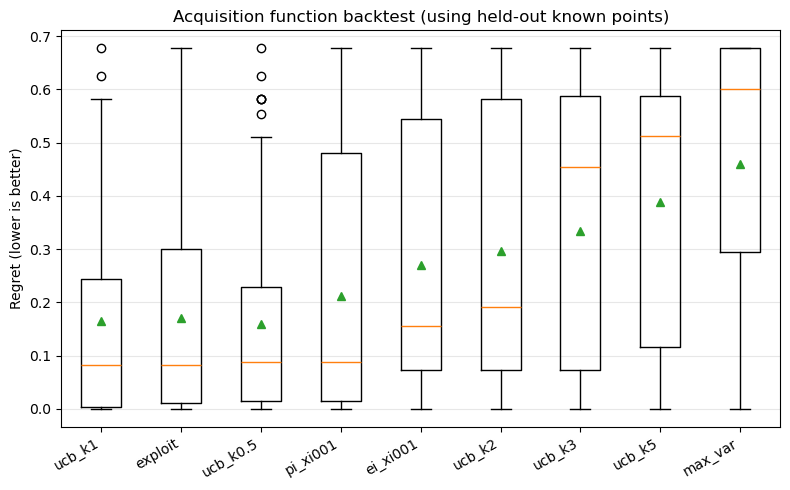

In [5]:
# kappa is dimensionless, so no row here needs a y-scaling correction. The UCB
# grid is finer than the rest because kappa is now the live dial -- carrying
# only kappa=1 and kappa=5 would say nothing about the region around the
# committed value. ei/pi stay as the comparison against last week's choice.
backtest_configs = [
    {"name": "ucb_k0.5", "acquisition": "ucb", "kappa": 0.5},
    {"name": "ucb_k1",   "acquisition": "ucb", "kappa": 1.0},
    {"name": "ucb_k2",   "acquisition": "ucb", "kappa": 2.0},
    {"name": "ucb_k3",   "acquisition": "ucb", "kappa": 3.0},
    {"name": "ucb_k5",   "acquisition": "ucb", "kappa": 5.0},
    {"name": "ei_xi001", "acquisition": "ei",  "xi": 0.01},   # last week's choice
    {"name": "pi_xi001", "acquisition": "pi",  "xi": 0.01},
    {"name": "exploit",  "acquisition": "exploit"},
    {"name": "max_var",  "acquisition": "max_variance"},
]

with fitting("acquisition backtest, 50 splits"):
    backtest_results = backtest_acquisitions(
        X, y, bounds, backtest_configs,
        n_repeats=50, seed_frac=0.5, maximize=True,
        gp_kwargs={"n_restarts_optimizer": 15}, random_state=0,
    )

print_backtest_summary(backtest_results)

# ---------------------------------------------------------------------------
# Which acquisition appears best on the evidence so far?
#
# Every config is scored on the SAME splits, so they are compared PAIRED: the
# per-split difference in regret is much less noisy than the two means
# separately, and its standard error says whether a gap is real. "Within noise"
# below means |mean difference| <= 2 standard errors. Plain arithmetic -- no
# statistical test involved.
# ---------------------------------------------------------------------------
CHOSEN = "ucb_k1"      # the family this notebook actually proposes with

names = list(backtest_results)
mean_r = {n: float(backtest_results[n]["regret"].mean()) for n in names}
med_r = {n: float(np.median(backtest_results[n]["regret"])) for n in names}
ranked = sorted(names, key=lambda n: mean_r[n])
leader = ranked[0]
n_splits = len(backtest_results[leader]["regret"])


def paired_gap(a, b):
    """Mean per-split regret difference (b - a), and its standard error."""
    d = backtest_results[b]["regret"] - backtest_results[a]["regret"]
    return float(d.mean()), float(d.std(ddof=1) / np.sqrt(len(d)))


tied = [n for n in ranked[1:] if abs(paired_gap(leader, n)[0])
        <= 2 * paired_gap(leader, n)[1]]
worse = [n for n in ranked[1:] if n not in tied]

print("\n=== which acquisition appears best in our tests so far? ===")
print(f"leader by mean regret   : {leader:>10}  ({mean_r[leader]:.4f})")
best_med = min(names, key=lambda n: med_r[n])
print(f"leader by median regret : {best_med:>10}  ({med_r[best_med]:.4f})"
      + ("   (agrees)" if best_med == leader else "   (DISAGREES with the mean)"))

print(f"\npaired against {leader}, over the same {n_splits} splits:")
for n in ranked[1:]:
    gap, se = paired_gap(leader, n)
    print(f"  {n:>10}: {gap:+.4f} +/- {se:.4f} ({gap / se:>4.1f} s.e.)"
          f"   {'within noise' if n in tied else 'clearly worse'}")

print(f"\nindistinguishable from the leader : {', '.join([leader] + tied)}")
print(f"clearly worse                     : {', '.join(worse) or 'none'}")

rank = ranked.index(CHOSEN) + 1
gap, se = paired_gap(leader, CHOSEN)
print(f"\nthis notebook proposes with {CHOSEN}: ranked {rank} of {len(ranked)}", end="")
if CHOSEN == leader:
    print(" -- it leads.")
else:
    print(f", {gap:+.4f} +/- {se:.4f} behind {leader}"
          f" ({'within noise' if CHOSEN in tied else 'a REAL gap'}).")


plot_acquisition_backtest(backtest_results)
plt.show()

## Sensitivity check: which dimension matters more right now

Cheap to check even in 2D -- worth knowing before staring at the contour plot. A length-scale pinned at the upper `length_scale_bounds` means the GP thinks that axis is close to irrelevant; only trust "pinned vs. not pinned", not the relative size of two pinned dimensions.

In [6]:
with fitting("shared GP for the sensitivity check"):
    gp_check = fit_gp(X, y, bounds, n_restarts_optimizer=20, random_state=0)

length_scales = get_length_scales(gp_check)
for dim, ls in sorted(enumerate(length_scales), key=lambda t: t[1]):
    tag = "(most sensitive)" if ls == length_scales.min() else ("(least sensitive)" if ls == length_scales.max() else "")
    print(f"x{dim}: length_scale = {ls:.3f} {tag}")

[fitting: shared GP for the sensitivity check] 1 warning held back:
     1 x  ConvergenceWarning  k1__k2__length_scale (dim 1) pinned at upper bound 10.0
x0: length_scale = 0.015 (most sensitive)
x1: length_scale = 10.000 (least sensitive)


## Compare kappa values before committing

This is the cell that actually decides `kappa`. Cheap, no real evaluation spent: fits ONE shared GP and shows where each candidate `kappa` would propose to search *right now*. Because the model is shared, any difference between rows is purely down to `kappa`, not GP-refit noise.

`kappa` is UCB's exploration weight in `mu + kappa*sigma`. Both terms are in `y`-units, so **`kappa` is dimensionless** — unlike EI's `xi` it needs no rescaling, and no change in `y`'s spread can ever mis-size it. That removes the one thing the no-y-scaling decision had to be re-checked against each week.

Two things to read, and the second matters more:

1. **Saturation** — does `x_next`/`dist_from_best` keep moving as `kappa` rises? Once proposals stop moving, a larger `kappa` buys nothing.
2. **Discontinuity** — does the proposal *jump*? This is the failure CLAUDE.md documents on function 4, and **function 2 still has one, but it moved -- and reversed direction -- after the week-4 point.**

The week-4 observation landed far out on `x1` (1.295) with an unremarkable `y`, and that taught the GP `x1` barely matters: its length-scale flipped from a moderate `0.489` to pinned at the *upper* `length_scale_bounds` (`10.0`), i.e. "irrelevant." With that axis flattened, `kappa` 0 through 2 -- including the previously-committed `kappa=1` -- all now land exactly on `x1`'s **lower bound (0.0)**, which is `lower_limit=0.0`, a real domain constraint, not a `pad_fraction` artifact. Even pure `exploit` (`kappa=0`) hits it, so this isn't an explore/exploit tradeoff, it's the flattened mean drifting to an edge. Only `kappa >= 3` clears that wall:

| `kappa` | proposal (this sweep) | on the `x1=0` floor? |
|---|---|---|
| 0.0 (exploit) | `[0.708, 0.000]` | yes |
| 1.0 (old choice) | `[0.717, 0.000]` | yes |
| 2.0 | `[0.726, 0.000]` | yes |
| 3.0 | `[0.928, 1.099]` | no |
| 5.0 | `[1.103, 1.503]` | no |
| 8.0 | `[0.944, 0.135]` | no |

So the usable range is now **`kappa >= 3`**, the opposite of last week's reading. (A convex-hull check on every one of these proposals comes back `False` -- but that's expected given how loose the box is relative to the data here, so it doesn't discriminate; the bound-contact column above does.) The backtest below still nominally favours low `kappa`/`exploit`, but per CLAUDE.md that reflects its structural bias toward exploitation on every function, not independent evidence -- it shouldn't override a direct bound-contact finding like this one.

**Caveat on this table's exact coordinates, not its pattern:** `compare_kappa_proposals` reuses one random-number stream across every row in the sweep, so later kappa values' multi-start optimisation can land in a different local mode than a standalone call would find -- confirmed here: the actual proposal cell below re-fits and re-optimises independently for `kappa=3` and finds a *better* peak, `[0.733, 1.624]` (UCB=1.081) vs. this table's `[0.928, 1.099]` (UCB=0.995). The wall-vs-no-wall pattern above is trustworthy; the exact numbers in this table are not the last word -- the proposal cell's own fit is.

[fitting: kappa sweep (one shared GP)] 1 warning held back:
     1 x  ConvergenceWarning  k1__k2__length_scale (dim 1) pinned at upper bound 10.0
   kappa |                   x_next |  acq_value |  pred_mean |  pred_std |  dist_from_best
-------------------------------------------------------------------------------------------
       0 |            [0.708,0.   ] |     0.6231 |     0.6231 |    0.0538 |          0.9266
     0.5 |            [0.712,0.   ] |     0.6585 |     0.6131 |    0.0908 |          0.9266
       1 |            [0.717,0.   ] |     0.7148 |     0.5814 |    0.1334 |          0.9267
       2 |            [0.726,0.   ] |     0.8795 |     0.5018 |    0.1888 |          0.9269
       3 |            [0.928,1.099] |     0.9946 |     0.2745 |    0.2400 |          0.2835
       5 |            [1.103,1.503] |     1.4731 |     0.2612 |    0.2424 |          0.7019
       8 |            [0.944,0.134] |     2.2024 |     0.2657 |    0.2421 |          0.8281

 kappa                 x_

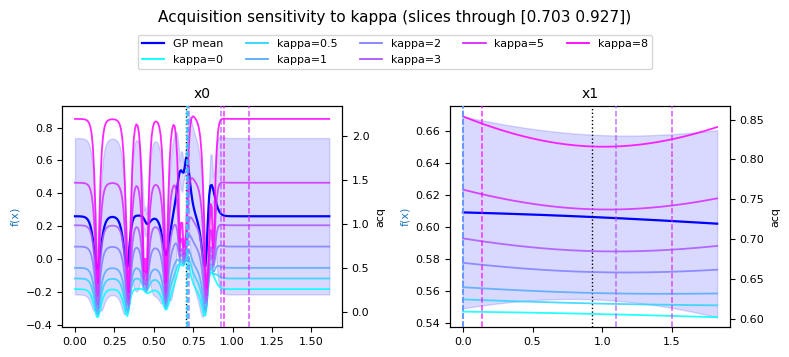


using kappa = 3.0 (dimensionless -- no y-scaling needed, ever)


In [7]:
with fitting("kappa sweep (one shared GP)"):
    kappa_rows = compare_kappa_proposals(X, y, bounds,
                                         kappa_values=[0.0, 0.5, 1.0, 2.0, 3.0, 5.0, 8.0],
                                         maximize=True, n_restarts=25, random_state=0)

print_kappa_comparison(kappa_rows)

# Flag bound contact and per-axis extrapolation, so the cliff described above is
# visible in the numbers rather than only in the prose.
print(f"\n{'kappa':>6} {'x_next':>22} {'on a bound':>12} {'outside observed range':>24}")
for r in kappa_rows:
    xn = np.asarray(r["x_next"])
    on_bound = [f"x{k}" for k in range(D)
                if np.isclose(xn[k], bounds[k, 0], atol=1e-6)
                or np.isclose(xn[k], bounds[k, 1], atol=1e-6)]
    outside = [f"x{k}" for k in range(D)
               if not (X[:, k].min() <= xn[k] <= X[:, k].max())]
    print(f"{r['kappa']:>6.1f} {str(np.round(xn, 4)):>22} {','.join(on_bound) or 'none':>12}"
          f" {','.join(outside) or 'none':>24}")
print("  -> a coordinate ON a bound means pad_fraction is choosing it, not the model.")

plot_kappa_sensitivity(X, y, bounds, gp_check, kappa_rows, ucb_acquisition, maximize=True)
plt.show()

# Committed choice -- dimensionless, and reused by the proposal, the contour
# plot, and the diagnostics replay below so they can't silently drift apart.
# Re-picked this week: kappa 0-2 (including the old choice, kappa=1) now land
# exactly on x1's real lower bound (0.0) because the week-4 point flattened
# x1's length-scale to "irrelevant" -- see the markdown above. kappa=3 is the
# first value that clears that wall.
KAPPA = 3.0
print(f"\nusing kappa = {KAPPA} (dimensionless -- no y-scaling needed, ever)")

## Propose the next point

In [8]:
with fitting("UCB proposal"):
    x_next, gp = generate_next_point(
        X, y, bounds,
        acquisition="ucb",
        kappa=KAPPA,        # see the kappa comparison above
        maximize=True,
        n_restarts=25,
        random_state=0,
    )

print(f"\n--- Next point to evaluate (bounds shape {bounds.shape}) ---")
print("x_next:", np.round(x_next, 4))
print(gp.kernel_)

mu, sigma = gp.predict(normalize(x_next.reshape(1, -1), bounds), return_std=True)
print(f"GP predicted mean: {mu[0]:.4g}, predicted std: {sigma[0]:.4g}")
print(f"UCB = mu + {KAPPA}*sigma = {mu[0] + KAPPA * sigma[0]:.4g}")
print(f"current best observed y: {y.max():.4g}"
      f"  -> predicted improvement: {mu[0] - y.max():+.4g}")

# UCB is only as trustworthy as the region it lands in, so check that explicitly
# rather than assuming the box bounds make it safe.
on_bound = [f"x{d}" for d in range(D)
            if np.isclose(x_next[d], bounds[d, 0], atol=1e-6)
            or np.isclose(x_next[d], bounds[d, 1], atol=1e-6)]
outside = [f"x{d}" for d in range(D)
           if not (X[:, d].min() <= x_next[d] <= X[:, d].max())]
print("\non a bound (pad_fraction choosing it, not the model):", ",".join(on_bound) or "none")
print("outside the observed range on its own axis:", ",".join(outside) or "none")
print(f"distance from the incumbent: {np.linalg.norm(x_next - X[np.argmax(y)]):.4f}")
assert np.all(x_next >= 0.0), "X is never negative -- proposal has a negative coordinate"

[fitting: UCB proposal] 1 warning held back:
     1 x  ConvergenceWarning  k1__k2__length_scale (dim 1) pinned at upper bound 10.0

--- Next point to evaluate (bounds shape (2, 2)) ---
x_next: [0.7327 1.6242]
1.03**2 * Matern(length_scale=[0.0153, 10], nu=2.5) + WhiteKernel(noise_level=0.00638)
GP predicted mean: 0.4417, predicted std: 0.2132
UCB = mu + 3.0*sigma = 1.081
current best observed y: 0.6112  -> predicted improvement: -0.1696

on a bound (pad_fraction choosing it, not the model): none
outside the observed range on its own axis: x1
distance from the incumbent: 0.6983


## Visualise the GP and acquisition function

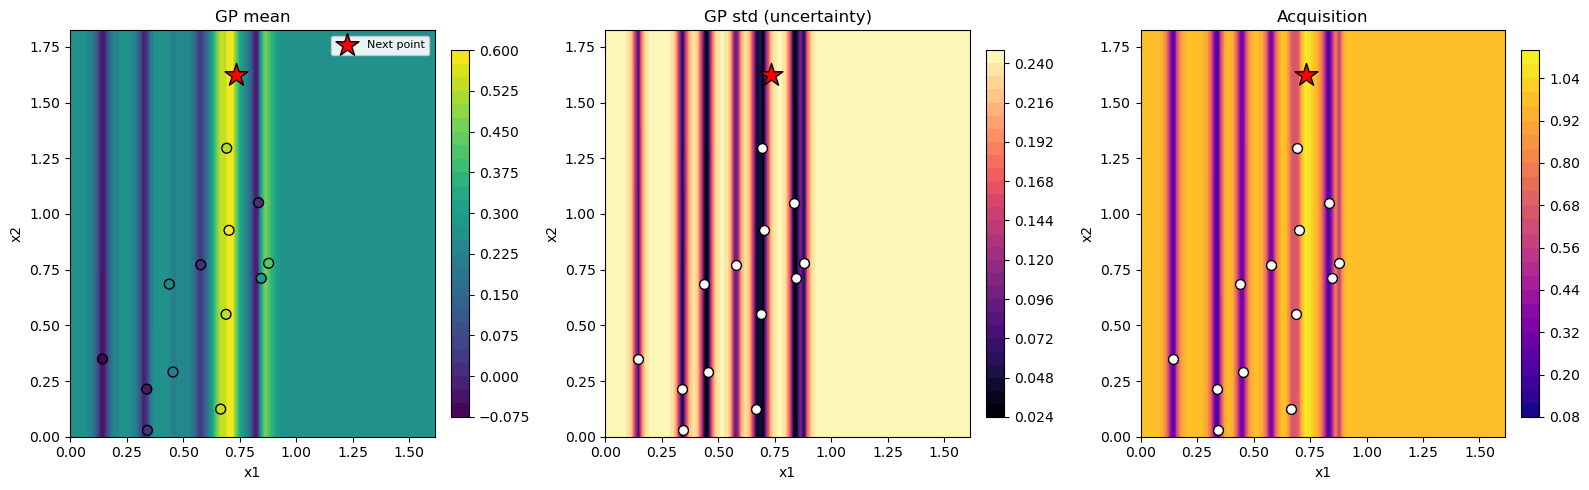

In [9]:
# ucb_acquisition takes no y_best: unlike EI it never references the incumbent,
# it just scores mu + kappa*sigma.
plot_2d_bo(
    X, y, bounds, gp,
    acquisition_fn=ucb_acquisition,
    x_next=x_next,
    acq_kwargs={"kappa": KAPPA, "maximize": True},
)
plt.show()

## Sanity-check the surrogate model: leave-one-out calibration

Refits the GP once per point, leaving that point out, and predicts it from the rest. At this many points the error bars are the thing to read -- whether the true values sit inside the predicted intervals -- rather than any tight correlation.

[fitting: leave-one-out calibration] 14 warnings held back, 2 distinct:
    11 x  ConvergenceWarning  k1__k2__length_scale (dim 1) pinned at upper bound 10.0
     3 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06


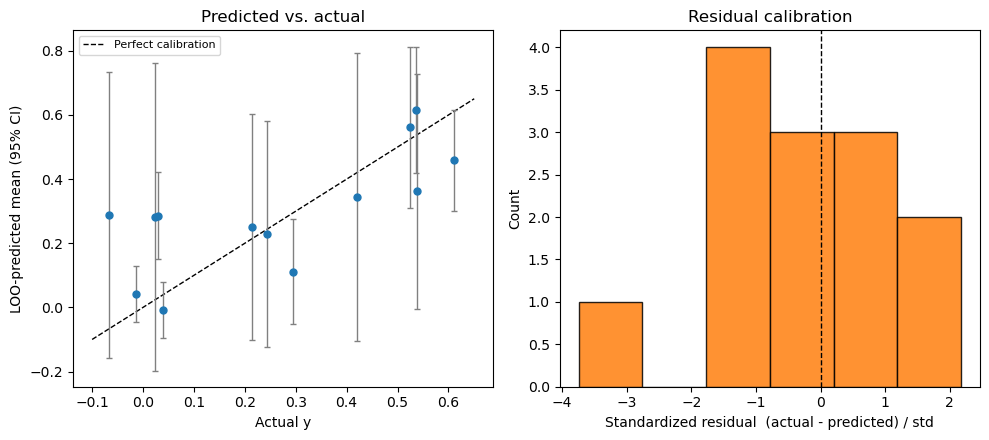

In [10]:
with fitting("leave-one-out calibration"):
    pred_mean, pred_std = loo_predictions(X, y, bounds,
                                          gp_kwargs={"n_restarts_optimizer": 20})

plot_loo_calibration(y, pred_mean, pred_std)
plt.show()

## Iteration diagnostics



[fitting: iteration-diagnostics replay] 3 warnings held back, 2 distinct:
     2 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06
     1 x  ConvergenceWarning  k1__k2__length_scale (dim 1) pinned at upper bound 10.0


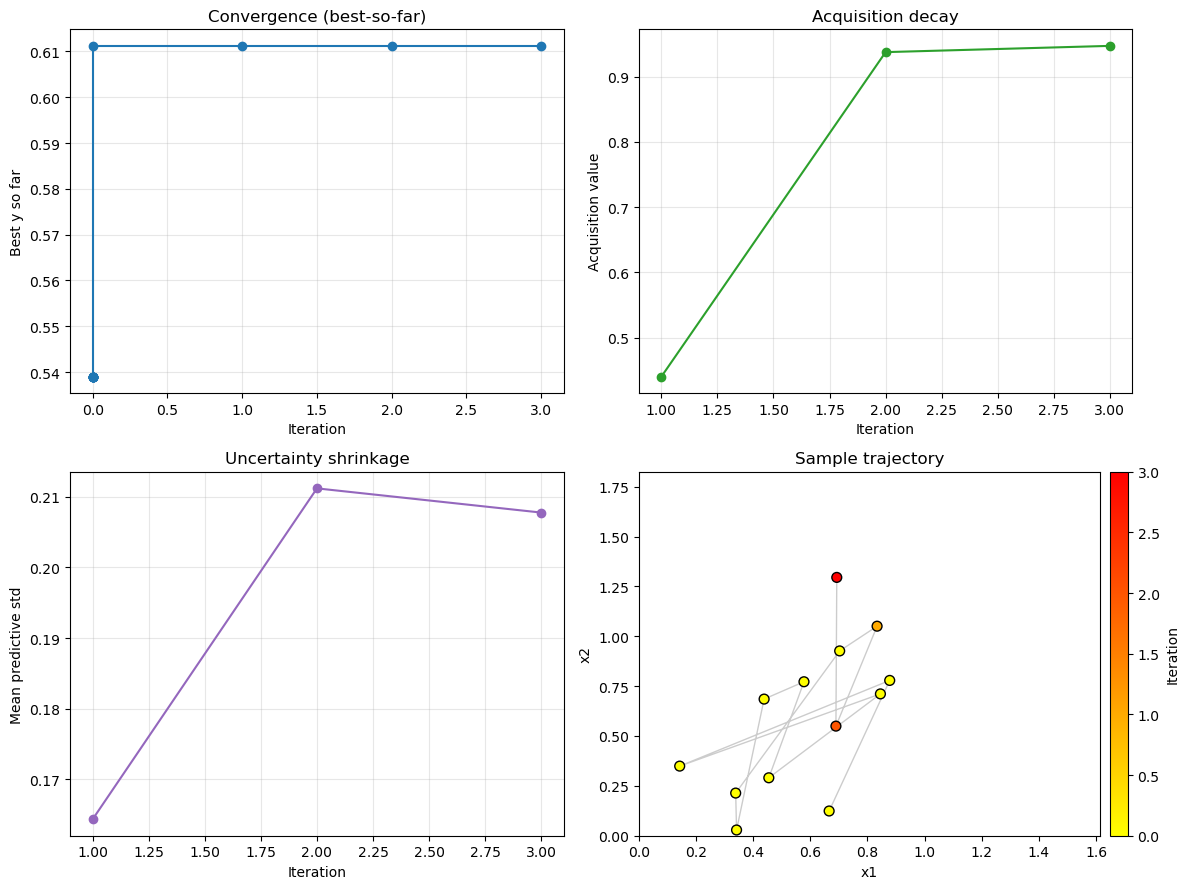

Best y so far: 0.6112052157614438


In [11]:
# The old `if len(new_y) == 0` guard is gone: new_y is populated above, so that
# branch was unreachable. Restore it only if this notebook is ever reset to a
# bare initial batch.
with fitting("iteration-diagnostics replay"):
    history = compute_iteration_diagnostics(X, y, bounds, n_initial=n_initial,
                                            acquisition="ucb", kappa=KAPPA,
                                            maximize=True)

plot_bo_diagnostics(history, bounds)
plt.show()

print("Best y so far:", np.nanmax(history["y"]))

## Raw diagnostic fields

In [12]:
print("y:", history["y"])
print("acq_value (NaN = initial batch):", history["acq_value"])
print("\nNOTE: BOTH collected points are artefacts in the acq_value column this")
print("week -- week 2 was proposed under ucb/kappa=5.0 and week 3 under ei/xi=0.01,")
print(f"while the replay above used ucb/kappa={KAPPA}, which matches neither. The")
print("column becomes meaningful from the first point proposed at this kappa.")
print("The GP-hyperparameter and domain_mean_std panels above are unaffected.")

y: [ 0.53899612  0.42058624 -0.06562362  0.29399291  0.21496451  0.02310555
  0.24461934  0.03874902 -0.01385762  0.61120522  0.0287878   0.53552257
  0.52410349]
acq_value (NaN = initial batch): [       nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan 0.44019175 0.93747212
 0.94705033]

NOTE: BOTH collected points are artefacts in the acq_value column this
week -- week 2 was proposed under ucb/kappa=5.0 and week 3 under ei/xi=0.01,
while the replay above used ucb/kappa=3.0, which matches neither. The
column becomes meaningful from the first point proposed at this kappa.
The GP-hyperparameter and domain_mean_std panels above are unaffected.


In [13]:
# The proposal as a hyphen-separated string, for submission.
print("-".join(f"{v:.6f}" for v in x_next))

# Full precision as well. 6 dp is fine to submit, but paste THIS into next
# week's new_X: a 6-dp copy of function 4's proposal rounded 4e-7 outside its
# own upper bound and tripped validate_bounds_consistency.
print("\nfull precision (use for next week's new_X):")
print("-".join(repr(float(v)) for v in x_next))

0.732692-1.624234

full precision (use for next week's new_X):
0.7326915242871554-1.6242335689999166
